In [71]:
import importlib
import scipy.io
import utils.utils as u 
import utils.preprocessing as p 
import utils.models as m 
import numpy as np
import mne
import polars as pl
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix
import numpy as np
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Reload modules to reflect recent changes:
importlib.reload(u)
importlib.reload(p)
importlib.reload(m)
# Notice we are inside of src directory
!ls -la

"ls" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


In [29]:
#Load files from directory of the experiment
files=u.get_file_names("../data", experiment="CLA")
print(files)

['../data/CLA-SubjectA-160108-3St-LRHand.mat', '../data/CLA-SubjectB-151019-3St-LRHand.mat', '../data/CLA-SubjectB-151020-3St-LRHand.mat', '../data/CLA-SubjectB-151215-3St-LRHand.mat', '../data/CLA-SubjectC-151126-3St-LRHand.mat', '../data/CLA-SubjectC-151216-3St-LRHand.mat', '../data/CLA-SubjectC-151223-3St-LRHand.mat', '../data/CLA-SubjectD-151125-3St-LRHand.mat', '../data/CLA-SubjectE-151225-3St-LRHand.mat', '../data/CLA-SubjectE-160119-3St-LRHand.mat', '../data/CLA-SubjectE-160122-3St-LRHand.mat', '../data/CLA-SubjectF-150916-3St-LRHand.mat', '../data/CLA-SubjectF-150917-3St-LRHand.mat', '../data/CLA-SubjectF-150928-3St-LRHand.mat', '../data/CLA-SubjectJ-170504-3St-LRHand-Inter.mat', '../data/CLA-SubjectJ-170508-3St-LRHand-Inter.mat', '../data/CLA-SubjectJ-170510-3St-LRHand-Inter.mat']


In [3]:
#BASELINE

#metadata, data = u.read_file(files[0])
#raw=u.read_file_to_raw(files[0])
#events = u.find_events_from_marker(data["marker"], metadata["sampling_freq"][0])
#epochs = mne.Epochs(raw=raw, events=events, tmin= -0.1, tmax= +0.5, baseline=(None, 0), preload=True)
#df = u.epochs_to_polars(epochs)
#u.quick_XGBOOST_test(df)



In [85]:
#For now let's just read work with one file - later we will loop over all files
metadata, data = u.read_file(files[0])
print(data.shape)
raw=u.read_file_to_raw(files[0])
raw.set_eeg_reference(ref_channels=['A1','A2'])
raw.drop_channels(['A1','A2'])
raw.resample(128, npad="auto") # resample to 250 Hz
print(raw.info)
#p.preprocess_eeg(raw)
#raw.compute_psd().plot()
#_=raw.plot()


(671600, 23)
Channels: ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'A1', 'A2', 'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'Fz', 'Cz', 'Pz']
Creating RawArray with float64 data, n_channels=21, n_times=671600
    Range : 0 ... 671599 =      0.000 ...  3357.995 secs
Ready.
Successfully created Raw object
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
<Info | 9 non-empty values
 bads: []
 ch_names: Fp1, Fp2, F3, F4, C3, C4, P3, P4, O1, O2, F7, F8, T3, T4, T5, ...
 chs: 19 EEG
 custom_ref_applied: True
 dig: 24 items (3 Cardinal, 21 EEG)
 highpass: 0.0 Hz
 lowpass: 64.0 Hz
 meas_date: unspecified
 nchan: 19
 projs: []
 sfreq: 128.0 Hz
>


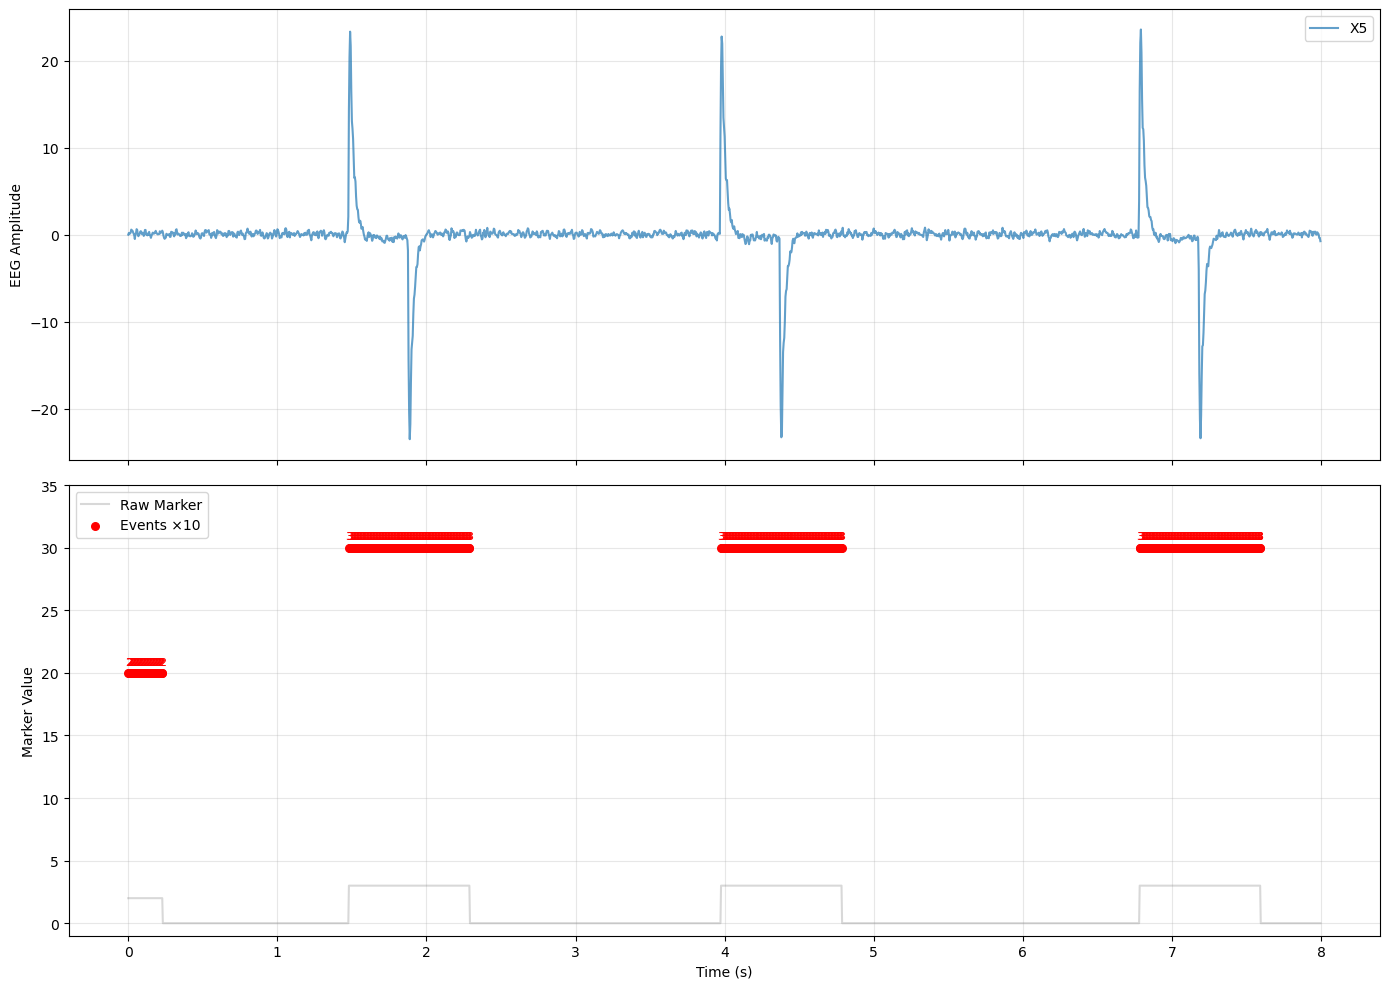

Events in this window: {2: 58, 3: 609}
{0: 476168, 1: 61490, 2: 69202, 3: 64740}


In [56]:
u.plot_eeg_signals_with_events(data, first_sample=50000, window_size=2000, freq=250, channels=[ "X5" ,"marker"])
# Count all unique values
unique_values, counts = np.unique(data["marker"], return_counts=True)
print(dict(zip(unique_values, counts)))


In [86]:
events = u.find_events_from_marker(data["marker"])
epochs = mne.Epochs(
        raw=raw,
        events=events,
        tmin= -0.5,  # Start before event
        tmax= +1,      # End after event
        baseline=(None, 0),       # Baseline correction
        preload=True
    )

LENGTH=len(epochs)
#epochs = p.augment_epochs(epochs, 250, ratio=2.0)
#epochs = p.preprocess_eeg(epochs)
print(epochs)
#df = u.epochs_to_polars(epochs)


Not setting metadata
1920 matching events found
Setting baseline interval to [-0.5, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 1920 events and 193 original time points ...
708 bad epochs dropped
<Epochs | 1212 events (all good), -0.5 – 1 s (baseline -0.5 – 0 s), ~33.9 MiB, data loaded,
 '0': 606
 '1': 200
 '2': 211
 '3': 195>


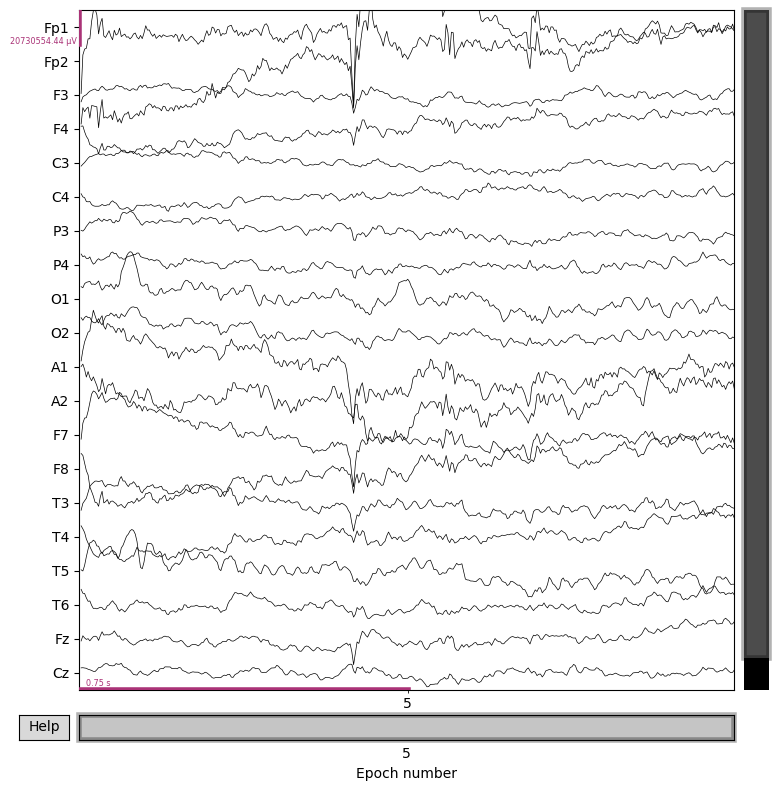

Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-12 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-12 dB cutoff frequency: 45.00 Hz)
- Filter length: 825 samples (3.300 s)



c:\Users\josub\Desktop\BDMA\Padova\Machine Learning\Proyect\PROJECT\src\utils\preprocessing.py:52: RuntimeWarning: filter_length (825) is longer than the signal (376), distortion is likely. Reduce filter length or filter a longer signal.
  epochs.filter(


EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.


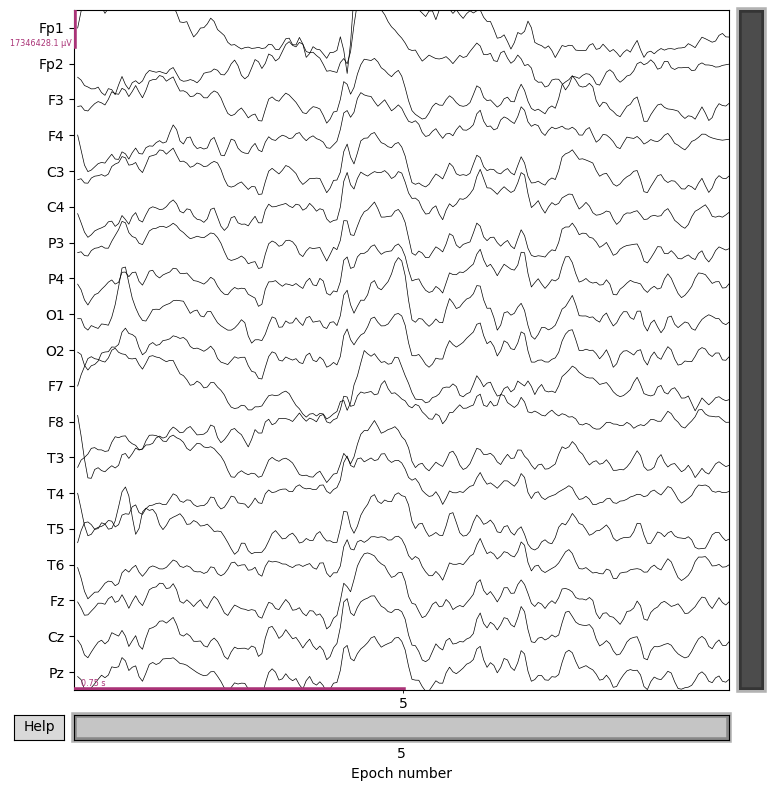

In [58]:
importlib.reload(p)
epochs[5].plot(title='Epoch 5', scalings='auto') 
epochs = p.preprocess_eeg(epochs)
epochs[5].plot(title='Epoch 5 preproccessed', scalings='auto') 
df = u.epochs_to_polars(epochs)

In [87]:
import matplotlib.pyplot as plt
import numpy as np

# Get data for two epochs
X = epochs.get_data()
index=50
epoch0 = X[index]
epoch1 = X[index+LENGTH]  # Choose another epoch for comparison

# Channel names
ch_names = epochs.info['ch_names']
sfreq = epochs.info['sfreq']
times = np.arange(epoch0.shape[1]) / sfreq

n_channels = len(ch_names)
fig, axes = plt.subplots(n_channels, 1, figsize=(12, 2*n_channels), sharex=True)

for i, ch in enumerate(ch_names):
    axes[i].plot(times, epoch0[i], label='Epoch {index}', color='blue')
    axes[i].plot(times, epoch1[i], label='Epoch {index} augmented', color='green', alpha=0.5)
    #axes[i].plot(times, epoch0[i]-epoch1[i], label='Difference', color='red', alpha=0.5)
    axes[i].set_ylabel(ch)
    axes[i].legend(loc='upper right')

axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()


IndexError: index 1262 is out of bounds for axis 0 with size 1212

In [88]:
channel_cols = df.columns[3:] 
C = len(channel_cols)  # number of channels
N = len(df['label'].unique())  # number of classes

rows_per_epoch = df.group_by("epoch_id").agg(pl.len().alias("rows_per_epoch"))
T = rows_per_epoch['rows_per_epoch'][0]  # first epoch row count

print(f"C: {C}, T: {T}, N: {N}")

# Convert to numpy array
X_np = df.select(channel_cols).to_numpy()  #(n_rows, C_channels)
# Number of epochs
n_epochs = df['epoch_id'].max() + 1  # assuming epoch_id starts from 0
# Reshape:
X_np = X_np.reshape(n_epochs,  C, T)
X_np = X_np[:, :, :, np.newaxis]      

# Labels
unique_labels = df["label"].unique().to_list()
unique_labels = sorted(unique_labels)
print("Original labels:", unique_labels)

# Map them to 0..N-1
label_map = {old: new for new, old in enumerate(unique_labels)}
print("Label map:", label_map)

# Apply mapping
y_np = df.group_by("epoch_id").first().select("label").to_numpy().flatten()
print("y_np before mapping:", y_np)
y_np = np.array([label_map[int(l)] for l in y_np])
y_np = to_categorical(y_np, num_classes=N)

print(f"X_np shape: {X_np.shape}, y_np shape: {y_np.shape}")

C: 19, T: 193, N: 4
Original labels: [0, 1, 2, 3]
Label map: {0: 0, 1: 1, 2: 2, 3: 3}
y_np before mapping: [1 0 0 ... 3 2 0]
X_np shape: (5760, 19, 193, 1), y_np shape: (5760, 4)


In [ ]:
#u.quick_XGBOOST_test(df)

(5760, 3667) (5760,)
Starting XGBoost training...
Training complete.

Model Accuracy on Test Set: 99.22%


In [89]:
C = len(df.columns)-3 # number of channels
T = df.group_by("epoch_id").agg(
    pl.count().alias("rows_per_epoch")
).select(
    pl.col("rows_per_epoch")
).head(1).item()

N = len(df["label"].unique()) # number of classes
print(f"C: {C}, T: {T}, N: {N}")



C: 19, T: 193, N: 4


C:\Users\josub\AppData\Local\Temp\ipykernel_30136\2107012675.py:3: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("rows_per_epoch")


In [90]:
channel_cols = df.columns[3:] 
C = len(channel_cols)  # number of channels
N = len(df['label'].unique())  # number of classes

rows_per_epoch = df.group_by("epoch_id").agg(pl.len().alias("rows_per_epoch"))
T = rows_per_epoch['rows_per_epoch'][0]  # first epoch row count

print(f"C: {C}, T: {T}, N: {N}")

# Convert to numpy array
X_np = df.select(channel_cols).to_numpy()  #(n_rows, C_channels)
# Number of epochs
n_epochs = df['epoch_id'].max() + 1  # assuming epoch_id starts from 0
# Reshape:
X_np = X_np.reshape(n_epochs,  C, T)
X_np = X_np[:, :, :, np.newaxis]      

# Labels
unique_labels = df["label"].unique().to_list()
unique_labels = sorted(unique_labels)
print("Original labels:", unique_labels)

# Map them to 0..N-1
label_map = {old: new for new, old in enumerate(unique_labels)}
print("Label map:", label_map)

# Apply mapping
y_np = df.group_by("epoch_id").first().select("label").to_numpy().flatten()
print("y_np before mapping:", y_np)
y_np = np.array([label_map[int(l)] for l in y_np])
y_np = to_categorical(y_np, num_classes=N)

print(f"X_np shape: {X_np.shape}, y_np shape: {y_np.shape}")

C: 19, T: 193, N: 4
Original labels: [0, 1, 2, 3]
Label map: {0: 0, 1: 1, 2: 2, 3: 3}
y_np before mapping: [1 0 0 ... 0 1 2]
X_np shape: (5760, 19, 193, 1), y_np shape: (5760, 4)


In [96]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

X_train, X_temp, y_train, y_temp = train_test_split(X_np, y_np, test_size=0.3, random_state=42, stratify=y_np)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

y_train_int = np.argmax(y_train, axis=1)
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_int),
    y=y_train_int
)

# Convert to dict {class_index: weight}
class_weights = dict(enumerate(class_weights_array))
print(class_weights)

print(X_train.shape, X_val.shape, X_test.shape)

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
checkpoint = ModelCheckpoint("best_model.h5", monitor='val_loss', save_best_only=True)


{0: 0.5, 1: 1.5899053627760253, 2: 1.411764705882353, 3: 1.5089820359281436}
(4032, 19, 193, 1) (864, 19, 193, 1) (864, 19, 193, 1)


In [97]:
shallow=m.ShallowConvNet(nb_classes=N,Chans = C, Samples =T , dropoutRate = 0.5)
shallow.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.000001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
shallow.summary()


C:\Users\josub\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 19, 193, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 19, 181, 40)    │           560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 1, 181, 40)     │        30,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 1, 181, 40)     │           160 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_21 (Activation)      │ (None, 1, 181, 40)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_11            │ (None, 1, 21, 40)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_22 (Activation)      │ (None, 1, 21, 40)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 1, 21, 40)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 840)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │         3,364 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_23 (Activation)      │ (None, 4)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,484 (134.70 KB)

 Trainable params: 34,404 (134.39 KB)

 Non-trainable params: 80 (320.00 B)

In [98]:
history =shallow.fit(
    X_train, y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_val, y_val),
    shuffle=True,
    callbacks=[early_stop, checkpoint],
    class_weight=class_weights
)
loss, acc = shallow.evaluate(X_test, y_test)
y_pred = shallow.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)   
# Confusion matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)
print(cm)

Epoch 1/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.2200 - loss: 1.7866

126/126 ━━━━━━━━━━━━━━━━━━━━ 12s 43ms/step - accuracy: 0.2240 - loss: 1.7136 - val_accuracy: 0.1991 - val_loss: 1.7736
Epoch 2/100
125/126 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.2264 - loss: 1.6854

126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.2277 - loss: 1.6892 - val_accuracy: 0.1979 - val_loss: 1.6013
Epoch 3/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.2309 - loss: 1.6755 - val_accuracy: 0.2049 - val_loss: 1.6554
Epoch 4/100
125/126 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.2308 - loss: 1.6818

126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - accuracy: 0.2326 - loss: 1.6638 - val_accuracy: 0.1979 - val_loss: 1.5352
Epoch 5/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.2356 - loss: 1.6642 - val_accuracy: 0.1956 - val_loss: 1.5799
Epoch 6/100
125/126 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.2245 - loss: 1.6454

126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.2294 - loss: 1.6658 - val_accuracy: 0.1968 - val_loss: 1.5055
Epoch 7/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.2326 - loss: 1.6393 - val_accuracy: 0.2002 - val_loss: 1.5358
Epoch 8/100
125/126 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.2429 - loss: 1.6216

...

126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.2331 - loss: 1.6465 - val_accuracy: 0.2280 - val_loss: 1.4563
Epoch 13/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - accuracy: 0.2485 - loss: 1.6387 - val_accuracy: 0.2141 - val_loss: 1.4592
Epoch 14/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.2453 - loss: 1.6110 - val_accuracy: 0.2118 - val_loss: 1.4607
Epoch 15/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.2417 - loss: 1.6285

126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.2416 - loss: 1.6219 - val_accuracy: 0.2002 - val_loss: 1.4526
Epoch 16/100
125/126 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.2471 - loss: 1.6059

126/126 ━━━━━━━━━━━━━━━━━━━━ 7s 57ms/step - accuracy: 0.2488 - loss: 1.6352 - val_accuracy: 0.2535 - val_loss: 1.4239
Epoch 17/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.2438 - loss: 1.6243 - val_accuracy: 0.2245 - val_loss: 1.4296
Epoch 18/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 7s 54ms/step - accuracy: 0.2426 - loss: 1.6332 - val_accuracy: 0.2269 - val_loss: 1.4466
Epoch 19/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - accuracy: 0.2540 - loss: 1.6299 - val_accuracy: 0.2338 - val_loss: 1.4443
Epoch 20/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - accuracy: 0.2574 - loss: 1.6093 - val_accuracy: 0.2245 - val_loss: 1.4407
Epoch 21/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step - accuracy: 0.2381 - loss: 1.6330 - val_accuracy: 0.2396 - val_loss: 1.4281
Epoch 22/100
125/126 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.2609 - loss: 1.5817

126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.2584 - loss: 1.6100 - val_accuracy: 0.3681 - val_loss: 1.3588
Epoch 23/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - accuracy: 0.2510 - loss: 1.6294 - val_accuracy: 0.2407 - val_loss: 1.4300
Epoch 24/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.2502 - loss: 1.6071 - val_accuracy: 0.2743 - val_loss: 1.4137
Epoch 25/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.2577 - loss: 1.6139 - val_accuracy: 0.2280 - val_loss: 1.4296
Epoch 26/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.2527 - loss: 1.6121 - val_accuracy: 0.2674 - val_loss: 1.4142
Epoch 27/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.2354 - loss: 1.6535 - val_accuracy: 0.2245 - val_loss: 1.4321
Epoch 28/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step - accuracy: 0.2557 - loss: 1.6001 - val_accuracy: 0.2338 - val_loss: 1.4280
Epoch 29/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - accuracy: 0.2592 - loss: 1.6079 - val_a

126/126 ━━━━━━━━━━━━━━━━━━━━ 8s 65ms/step - accuracy: 0.2674 - loss: 1.5907 - val_accuracy: 0.3623 - val_loss: 1.3583
Epoch 33/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 7s 57ms/step - accuracy: 0.2522 - loss: 1.6073 - val_accuracy: 0.2060 - val_loss: 1.4490
Epoch 34/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.2562 - loss: 1.6246 - val_accuracy: 0.2870 - val_loss: 1.4031
Epoch 35/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.2572 - loss: 1.6365 - val_accuracy: 0.2292 - val_loss: 1.4321
Epoch 36/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.2666 - loss: 1.5944 - val_accuracy: 0.2778 - val_loss: 1.4053
Epoch 37/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step - accuracy: 0.2557 - loss: 1.5992 - val_accuracy: 0.2431 - val_loss: 1.4245
Epoch 38/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - accuracy: 0.2388 - loss: 1.6362 - val_accuracy: 0.3634 - val_loss: 1.3612
Epoch 39/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - accuracy: 0.2636 - loss: 1.6095 - val_

In [82]:
eegnet = m.EEGNet(nb_classes=N,Chans = C, Samples =T ,  dropoutRate = 0.5)
eegnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
eegnet.summary()


C:\Users\josub\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 19, 193, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 19, 193, 8)     │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 19, 193, 8)     │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_2              │ (None, 1, 193, 16)     │           304 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 1, 193, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 1, 193, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_6             │ (None, 1, 48, 16)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1, 48, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_2              │ (None, 1, 48, 16)      │           512 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 1, 48, 16)      │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 1, 48, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_7             │ (None, 1, 6, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 1, 6, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           388 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax (Activation)            │ (None, 4)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,876 (7.33 KB)

 Trainable params: 1,796 (7.02 KB)

 Non-trainable params: 80 (320.00 B)

In [ ]:
history =eegnet.fit(
    X_train, y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_val, y_val),
    shuffle=True,
    callbacks=[early_stop, checkpoint],
    class_weight=class_weights
)
loss, acc = eegnet.evaluate(X_test, y_test)
y_pred = eegnet.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)   
# Confusion matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)
print(cm)

Epoch 1/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - accuracy: 0.2507 - loss: 1.4002 - val_accuracy: 0.2905 - val_loss: 1.3850
Epoch 2/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.2408 - loss: 1.3990 - val_accuracy: 0.3079 - val_loss: 1.3837
Epoch 3/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - accuracy: 0.2502 - loss: 1.3976 - val_accuracy: 0.2905 - val_loss: 1.3857
Epoch 4/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - accuracy: 0.2463 - loss: 1.3986 - val_accuracy: 0.3090 - val_loss: 1.3838
Epoch 5/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.2478 - loss: 1.4017 - val_accuracy: 0.3009 - val_loss: 1.3841
Epoch 6/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - accuracy: 0.2510 - loss: 1.3987 - val_accuracy: 0.3044 - val_loss: 1.3846
Epoch 7/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - accuracy: 0.2579 - loss: 1.3960 - val_accuracy: 0.3090 - val_loss: 1.3839
Epoch 8/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - accuracy: 0.2587 - loss: 1.3952 -

In [194]:
inception = m.Inception(nb_classes=N,Chans = C, Samples =T )
inception.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
inception.summary()


(None, 19, 301)


Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_20      │ (None, 19, 301)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_331 (Conv1D) │ (None, 19, 12)    │      3,624 │ input_layer_20[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_45    │ (None, 19, 301)   │          0 │ input_layer_20[0… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_332 (Conv1D) │ (None, 19, 12)    │      2,892 │ conv1d_331[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_333 (Conv1D) │ (None, 19, 12)    │      8,652 │ conv1d_331[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_334 (Conv1D) │ (None, 19, 12)    │     14,412 │ conv1d_331[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_335 (Conv1D) │ (None, 19, 12)    │     21,612 │ conv1d_331[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_336 (Conv1D) │ (None, 19, 12)    │     28,812 │ conv1d_331[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_337 (Conv1D) │ (None, 19, 12)    │      3,624 │ max_pooling1d_45… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_45      │ (None, 19, 72)    │          0 │ conv1d_332[0][0], │
│ (Concatenate)       │                   │            │ conv1d_333[0][0], │
│                     │                   │            │ conv1d_334[0][0], │
│                     │                   │            │ conv1d_335[0][0], │
│                     │                   │            │ conv1d_336[0][0], │
│                     │                   │            │ conv1d_337[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 19, 72)    │        288 │ concatenate_45[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_69       │ (None, 19, 72)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_338 (Conv1D) │ (None, 19, 12)    │        876 │ activation_69[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_46    │ (None, 19, 72)    │          0 │ activation_69[0]… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_339 (Conv1D) │ (None, 19, 12)    │      2,892 │ conv1d_338[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_340 (Conv1D) │ (None, 19, 12)    │      8,652 │ conv1d_338[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_341 (Conv1D) │ (None, 19, 12)    │     14,412 │ conv1d_338[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_342 (Conv1D) │ (None, 19, 12)    │     21,612 │ conv1d_338[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_343 (Conv1D) │ (None, 19, 12)    │     28,812 │ conv1d_338[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_344 (Conv1D) │ (None, 19, 12)    │        876 │ max_pooling1d_46

 Total params: 505,612 (1.93 MB)

 Trainable params: 504,748 (1.93 MB)

 Non-trainable params: 864 (3.38 KB)

In [197]:
history = inception.fit(
    X_train, y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_val, y_val),
    shuffle=True,
    callbacks=[early_stop, checkpoint],
    class_weight=class_weights
)


Epoch 1/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.3364 - loss: 1.4509

42/42 ━━━━━━━━━━━━━━━━━━━━ 19s 74ms/step - accuracy: 0.2738 - loss: 1.4464 - val_accuracy: 0.5000 - val_loss: 1.2494
Epoch 2/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.1650 - loss: 1.4113

42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.2024 - loss: 1.4166 - val_accuracy: 0.5000 - val_loss: 1.2453
Epoch 3/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.2500 - loss: 1.4151 - val_accuracy: 0.5000 - val_loss: 1.2501
Epoch 4/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - accuracy: 0.2411 - loss: 1.4147 - val_accuracy: 0.5000 - val_loss: 1.2677
Epoch 5/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.2039 - loss: 1.4087 - val_accuracy: 0.5000 - val_loss: 1.2842
Epoch 6/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - accuracy: 0.1905 - loss: 1.4055 - val_accuracy: 0.5000 - val_loss: 1.3008
Epoch 7/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.1949 - loss: 1.4043 - val_accuracy: 0.5000 - val_loss: 1.3123
Epoch 8/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.1949 - loss: 1.4033 - val_accuracy: 0.5000 - val_loss: 1.3365
Epoch 9/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.1920 - loss: 1.4033 - val_accuracy: 0.1597 - val_l

In [198]:
loss, acc = inception.evaluate(X_test, y_test)
y_pred = inception.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)   
# Confusion matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)
print(cm)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5000 - loss: 1.2457
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step
[[144   0   0   0]
 [ 45   0   0   0]
 [ 51   0   0   0]
 [ 48   0   0   0]]
